# 05 - K-Means Customer Segmentation

El objetivo de este notebook es identificar grupos de clientes mediante K-Means, un algoritmo de clustering no supervisado que agrupa observaciones según su similitud en un espacio multivariable.

A diferencia de la segmentación RFM, basada en reglas definidas a partir de recencia, frecuencia y gasto, K-Means permite explorar la estructura de los datos utilizando simultáneamente diferentes características del cliente.

El análisis incluirá la selección y preparación de variables, el escalado delos datos, la elección del número de clusters, el entrenamiento de K-Means y la evaluación e interpretación de los grupos obtenidos.

## Estructura

1. Carga de datos preparados
2. Selección de variables para clustering
3. Preparación de los datos
4. Selección del número de clusters
5. Entrenamiento de K-Means
6. Evaluación de los clusters
7. Visualización mediante PCA
8. Conclusiones

In [45]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

## 1. Carga de los datos preparados

Se utiliza el dataset generado durante la fase de preparación de datos, que contiene las variables originales junto con las características derivadas necesarias para los análisis de segmentación.

In [46]:
DATA_PATH = Path("../data/processed/customer_segmentation_prepared.csv")

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["Dt_Customer"]
)

df.shape

(2240, 33)

## 2. Selección de variables para clustering

K-Means calcula la similitud entre clientes a partir de distancias entre sus características. Por este motivo, la selección de variables determina directamente la estructura de los clusters obtenidos.

No se utilizarán automáticamente todas las variables disponibles. El dataset contiene identificadores, variables redundantes y características que pueden reservarse para el perfilado posterior de los segmentos.

La selección buscará representar dimensiones diferentes del cliente evitando que una misma característica tenga un peso excesivo por estar representada simultáneamente mediante una variable agregada y sus componentes.

### 2.1 Variables candidatas

Se selecciona inicialmente un conjunto reducido de variables que representan distintas dimensiones del cliente: perfil demográfico, capacidad económica, estructura del hogar, antigüedad, actividad reciente e intensidad y valor de compra.

Esta selección se considera provisional. Antes del clustering se analizarán las distribuciones, relaciones y valores extremos de estas características, ya que K-Means es sensible a la escala y a observaciones alejadas del resto de los datos.

In [47]:
candidate_features = [
    "Age",
    "Income",
    "Children",
    "CustomerTenure",
    "Recency",
    "TotalPurchases",
    "TotalSpend"
]

df[candidate_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2240.0,45.194196,11.984069,18.0,37.00,44.0,55.00,121.0
Income,2240.0,52242.594866,25039.061738,1730.0,35538.75,51498.5,68289.75,666666.0
Children,2240.0,0.950446,0.751803,0.0,0.00,1.0,1.00,3.0
CustomerTenure,2240.0,353.582143,202.122512,0.0,180.75,355.5,529.00,699.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
TotalPurchases,2240.0,12.537054,7.205741,0.0,6.00,12.0,18.00,32.0
TotalSpend,2240.0,605.798214,602.249288,5.0,68.75,396.0,1045.50,2525.0


In [48]:
df[candidate_features].skew().sort_values(ascending=False)

Income            6.799483
TotalSpend        0.860841
Children          0.415970
Age               0.349944
TotalPurchases    0.297114
Recency          -0.001987
CustomerTenure   -0.015216
dtype: float64

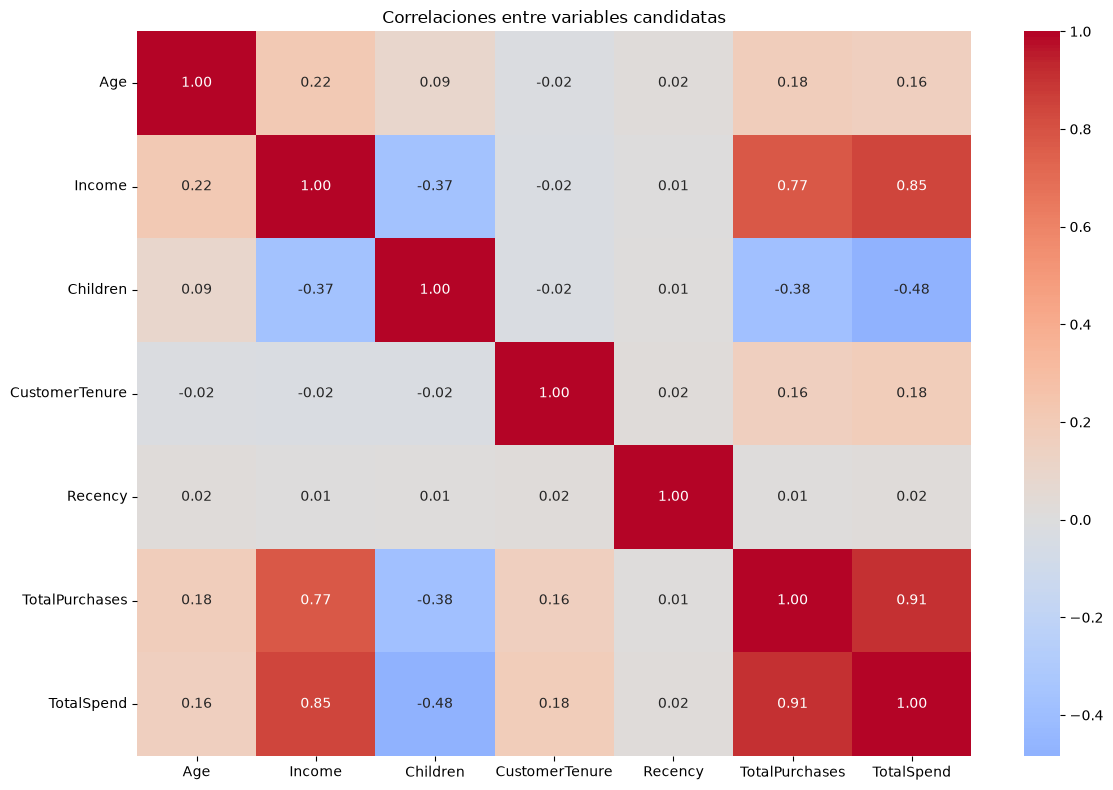

In [49]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[candidate_features].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlaciones entre variables candidatas")
plt.tight_layout()
plt.show()

### 2.2 Evaluación de redundancia y valores extremos

El análisis de correlaciones muestra una asociación elevada entre algunas delas variables candidatas.

`TotalPurchases` y `TotalSpend` presentan una correlación de Spearman de 0,91, mientras que `Income` también muestra asociaciones elevadas con ambas variables (0,77 y 0,85, respectivamente).

Incluir simultáneamente variables muy correlacionadas puede otorgar un peso excesivo a una misma dimensión del comportamiento en un algoritmo basado en distancias como K-Means.

Por otro lado, `Income` presenta inicialmente una asimetría positiva muy elevada (6,80) y un valor máximo de 666.666, considerablemente alejado del resto de observaciones. `Age` también alcanza un máximo de 121 años.

Antes de construir el modelo se analizará específicamente la magnitud de estas observaciones.

### 2.3 Análisis de valores extremos para clustering

Durante el análisis exploratorio se identificaron observaciones extremas en `Age` e `Income`. Al no existir evidencia suficiente para considerarlas errores, estos valores se conservaron durante la preparación de los datos.

Sin embargo, K-Means utiliza distancias para construir los clusters, por lo que las observaciones extremas pueden ejercer una influencia considerable sobre los centroides.

Por este motivo, se evalúa específicamente su magnitud antes de decidir cómo tratar estas variables en el espacio de clustering.

In [50]:
df["Age"].sort_values(ascending=False).head(10)

239     121
339     115
192     114
1950     74
424      73
894      71
1923     71
358      71
39       71
1150     71
Name: Age, dtype: int64

In [51]:
df["Age"].quantile([0.95, 0.99, 0.995, 1.00])

0.950     64.000
0.990     69.000
0.995     70.805
1.000    121.000
Name: Age, dtype: float64

In [52]:
df["Income"].sort_values(ascending=False).head(15)

2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
1898    113734.0
646     105471.0
252     102692.0
203     102160.0
124     101970.0
650      98777.0
1113     98777.0
Name: Income, dtype: float64

In [53]:
df["Income"].quantile([0.95, 0.99, 0.995, 1.00])

0.950     83927.00
0.990     94437.68
0.995    102122.95
1.000    666666.00
Name: Income, dtype: float64

In [54]:
df.nlargest(10, "Income")[
    ["ID", "Age", "Income", "TotalPurchases", "TotalSpend"]
]

,ID,Age,Income,TotalPurchases,TotalSpend
2233,9432,37,666666.0,7,62
617,1503,38,162397.0,1,107
687,1501,32,160803.0,29,1717
1300,5336,43,157733.0,2,59
164,8475,41,157243.0,22,1608
1653,4931,37,157146.0,28,1730
2132,11181,65,156924.0,0,8
655,5555,39,153924.0,0,6
1898,4619,69,113734.0,27,277
646,4611,44,105471.0,30,1724


El análisis confirma la presencia de observaciones extremadamente alejadas del resto de la distribución.

En `Age` aparecen tres clientes con edades de 114, 115 y 121 años, mientras que el siguiente valor observado es 74 años. En `Income`, el valor máximo de 666.666 se encuentra claramente aislado del resto, siendo más de cuatro veces superior al segundo ingreso más elevado.

Aunque estas observaciones se conservaron durante Data Preparation al no poder confirmarse que fueran errores, su influencia puede ser especialmente elevada en K-Means debido al uso de distancias y centroides.

In [55]:
extreme_mask = (
    (df["Age"] > 100)
    | (df["Income"] > 200000)
)

df.loc[
    extreme_mask,
    ["ID", "Age", "Income", "Children", "Recency", "TotalPurchases", "TotalSpend"]
]

,ID,Age,Income,Children,Recency,TotalPurchases,TotalSpend
192,7829,114,36640.0,1,99,5,65
239,11004,121,60182.0,1,23,3,22
339,1150,115,83532.0,0,36,14,1853
2233,9432,37,666666.0,1,23,7,62


### 2.4 Muestra utilizada para clustering

Se identifican cuatro clientes con observaciones extremas: tres presentan edades superiores a 100 años y uno registra un ingreso de 666.666.

Estas observaciones representan únicamente 4 de los 2.240 clientes del dataset y se encuentran claramente aisladas del resto de sus respectivas distribuciones.

Dado que K-Means es sensible a valores extremos, estos clientes se excluyen únicamente de la muestra utilizada para estimar los clusters. El dataset preparado original se mantiene intacto y no se imputan valores alternativos, ya que no existe información suficiente para determinar cuáles serían los valores correctos.

In [56]:
df_cluster = df.loc[~extreme_mask].copy()

print(f"Muestra original: {len(df)} clientes")
print(f"Observaciones excluidas: {extreme_mask.sum()}")
print(f"Muestra para clustering: {len(df_cluster)} clientes")

Muestra original: 2240 clientes
Observaciones excluidas: 4
Muestra para clustering: 2236 clientes


### 2.5 Selección definitiva de variables

Para construir el espacio de clustering se seleccionan variables que representan dimensiones diferentes del cliente:

- `Age`: edad del cliente.
- `Income`: nivel de ingresos.
- `Children`: número de menores en el hogar.
- `CustomerTenure`: antigüedad como cliente.
- `Recency`: tiempo transcurrido desde la última compra.
- `TotalSpend`: gasto acumulado.

`TotalPurchases` no se incluye en el modelo debido a su elevada asociación con `TotalSpend` (Spearman = 0,91). Incluir ambas variables otorgaría un peso adicional a una misma dimensión del comportamiento de compra.

Las variables relacionadas con categorías de producto, canales y campañas se reservan para el perfilado posterior de los clusters, evitando que la segmentación quede condicionada directamente por dichas características.

In [57]:
clustering_features = [
    "Age",
    "Income",
    "Children",
    "CustomerTenure",
    "Recency",
    "TotalSpend"
]

X = df_cluster[clustering_features].copy()

X.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2236.0,45.101968,11.703281,18.0,37.00,44.0,55.00,74.0
Income,2236.0,51957.241726,21412.823998,1730.0,35502.50,51445.5,68275.75,162397.0
Children,2236.0,0.950805,0.752204,0.0,0.00,1.0,1.00,3.0
CustomerTenure,2236.0,353.773256,202.181561,0.0,180.75,356.0,529.00,699.0
Recency,2236.0,49.116279,28.957284,0.0,24.00,49.0,74.00,99.0
TotalSpend,2236.0,605.986583,601.865156,5.0,69.00,396.5,1045.50,2525.0


In [58]:
X.skew().sort_values(ascending=False)

TotalSpend        0.860174
Children          0.415519
Income            0.350047
Age               0.092495
Recency          -0.004299
CustomerTenure   -0.016397
dtype: float64

In [59]:
X[["Income", "TotalSpend"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2236.0,51957.241726,21412.823998,1730.0,35502.5,51445.5,68275.75,162397.0
TotalSpend,2236.0,605.986583,601.865156,5.0,69.0,396.5,1045.50,2525.0


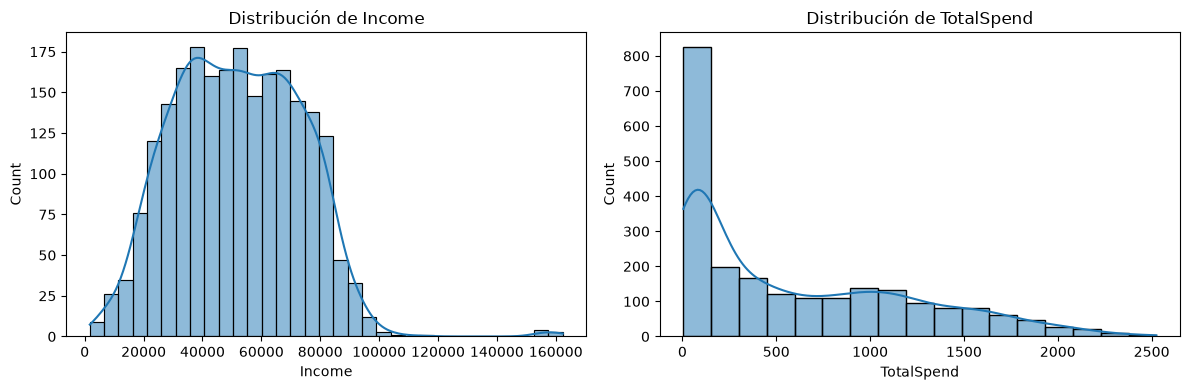

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=X, x="Income", kde=True, ax=axes[0])
axes[0].set_title("Distribución de Income")

sns.histplot(data=X, x="TotalSpend", kde=True, ax=axes[1])
axes[1].set_title("Distribución de TotalSpend")

plt.tight_layout()
plt.show()

## 3. Preparación de los datos

Tras excluir las cuatro observaciones extremas utilizadas únicamente para el clustering, las variables seleccionadas presentan distribuciones adecuadas para continuar con el análisis.

`Income` reduce considerablemente su asimetría tras retirar el valor extremo de 666.666, mientras que `Age`, `Recency` y `CustomerTenure` presentan distribuciones prácticamente simétricas.

`TotalSpend` mantiene una asimetría positiva moderada. Se decide conservar su escala original antes de la estandarización, ya que la distribución no presenta una asimetría extrema y las diferencias de gasto constituyen información relevante para la segmentación de clientes.

### 3.1 Estandarización de las variables

K-Means utiliza distancias euclídeas para asignar cada observación al centroide más cercano. Por este motivo, las diferencias de escala entre variables pueden condicionar fuertemente el resultado.

Las características seleccionadas presentan unidades y rangos muy diferentes. Para otorgar a cada variable una escala comparable se aplica `StandardScaler`, que transforma cada característica para que tenga aproximadamente media 0 y desviación estándar 1.

In [61]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(2236, 6)

In [62]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X.index
)

X_scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2236.0,6.514368e-17,1.000224,-2.316276,-0.692437,-0.094180,0.845938,2.469777
Income,2236.0,-1.000988e-16,1.000224,-2.346186,-0.768625,-0.023904,0.762261,5.158799
Children,2236.0,7.944351e-17,1.000224,-1.264308,-1.264308,0.065416,0.065416,2.724862
CustomerTenure,2236.0,2.542192e-17,1.000224,-1.750171,-0.855973,0.011016,0.866874,1.707891
Recency,2236.0,-7.149916e-17,1.000224,-1.696543,-0.867550,-0.004016,0.859517,1.723051
TotalSpend,2236.0,4.766610e-18,1.000224,-0.998764,-0.892404,-0.348140,0.730416,3.189157


## 4. Selección del número de clusters

K-Means requiere definir previamente el número de clusters (`k`). Para evitar seleccionar este parámetro de forma arbitraria, se evaluarán diferentes soluciones mediante dos criterios complementarios:

- **Inercia:** suma de las distancias cuadráticas de las observaciones respecto
  al centroide de su cluster. Disminuye a medida que aumenta `k`, por lo que se
  busca un punto a partir del cual la mejora adicional sea reducida.

- **Silhouette Score:** evalúa simultáneamente la cohesión interna de los
  clusters y su separación respecto a otros grupos. Valores más elevados
  indican una estructura de clustering mejor definida.

Ambos criterios se analizarán conjuntamente antes de seleccionar el número definitivo de clusters.

### 4.1 Evaluación de diferentes valores de k

Se entrenan soluciones comprendidas entre `k=2` y `k=10` para analizar la evolución de la inercia y del Silhouette Score.

In [63]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

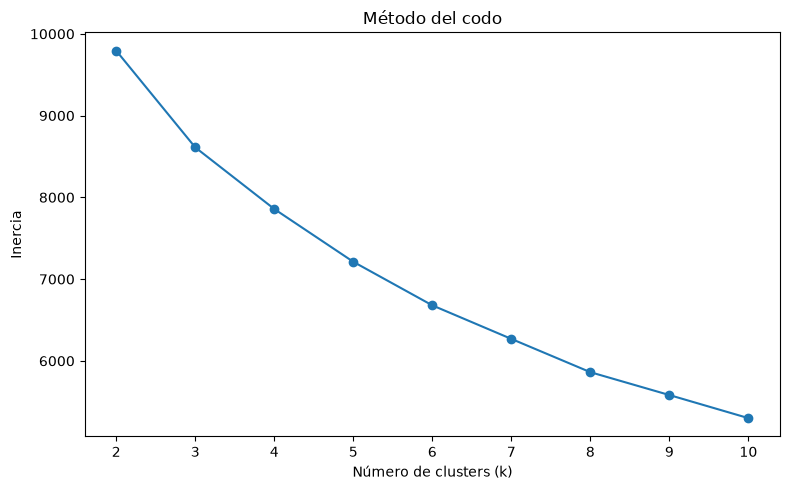

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

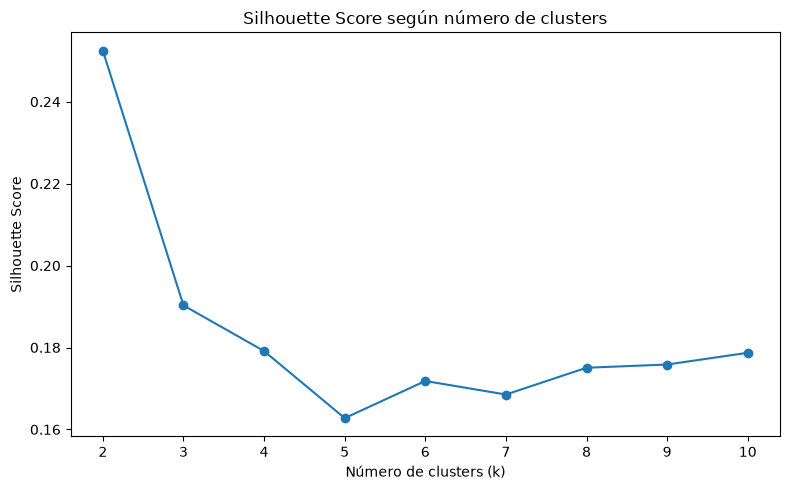

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.title("Silhouette Score según número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))

plt.tight_layout()
plt.show()

In [66]:
k_evaluation = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouette_scores
})

k_evaluation

,k,Inertia,Silhouette
0,2,9793.856851,0.252441
1,3,8611.351418,0.190276
2,4,7857.613669,0.179122
3,5,7211.839597,0.162763
4,6,6679.033464,0.171826
5,7,6268.621269,0.168522
6,8,5861.453062,0.175063
7,9,5581.805186,0.175846
8,10,5299.459203,0.178712


### 4.2 Análisis de soluciones candidatas

El Silhouette Score favorece claramente una solución de dos clusters. Sin embargo, antes de seleccionar definitivamente `k`, se comparan las soluciones de dos y tres grupos para analizar su tamaño e interpretación.

Esta comprobación permite determinar si el tercer cluster aporta una estructura adicional relevante o simplemente fragmenta grupos que no presentan una separación suficientemente clara.

In [67]:
candidate_results = {}

for k in [2, 3]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    candidate_results[k] = {
        "model": model,
        "labels": labels
    }

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
        .to_frame("Customers")
    )

    cluster_sizes["Percentage"] = (
        cluster_sizes["Customers"] / len(labels) * 100
    ).round(2)

    print(f"\nk = {k}")
    display(cluster_sizes)


k = 2


,Customers,Percentage
0,878,39.27
1,1358,60.73



k = 3


,Customers,Percentage
0,715,31.98
1,803,35.91
2,718,32.11


In [68]:
for k in [2, 3]:
    model = candidate_results[k]["model"]

    centers_original = scaler.inverse_transform(
        model.cluster_centers_
    )

    centers_df = pd.DataFrame(
        centers_original,
        columns=clustering_features
    ).round(2)

    print(f"\nCentroides para k = {k}")
    display(centers_df)


Centroides para k = 2


,Age,Income,Children,CustomerTenure,Recency,TotalSpend
0,47.45,72381.95,0.46,377.55,49.89,1241.41
1,43.58,38727.09,1.27,338.37,48.61,194.39



Centroides para k = 3


,Age,Income,Children,CustomerTenure,Recency,TotalSpend
0,36.92,31952.37,0.84,364.04,47.70,150.77
1,46.51,73388.23,0.40,378.46,49.69,1286.39
2,51.66,47888.25,1.67,316.01,49.88,298.14


La solución con dos clusters divide la muestra en grupos de 878 y 1.358 clientes, equivalentes aproximadamente al 39 % y 61 % de la muestra utilizada para clustering.

Al utilizar tres clusters se obtienen grupos de 715, 803 y 718 clientes, respectivamente. La distribución es notablemente equilibrada, sin que aparezcan clusters residuales formados por un número reducido de observaciones.

Además, los centroides de la solución de tres clusters muestran perfiles diferenciados principalmente en edad, ingresos, número de hijos y gasto total. Por el contrario, la recencia presenta valores medios similares entre los tres grupos.

Aunque `k=2` obtiene un Silhouette Score superior, `k=3` proporciona una segmentación más granular y mantiene tamaños de cluster equilibrados.

### 4.3 Estabilidad de la solución candidata

K-Means puede converger a soluciones diferentes dependiendo de la inicialización de los centroides. Aunque el uso de múltiples inicializaciones reduce este riesgo, se evalúa adicionalmente la estabilidad de la solución candidata de tres clusters utilizando diferentes semillas aleatorias.

Las particiones resultantes se comparan mediante el Adjusted Rand Index (ARI), una métrica que permite medir el grado de coincidencia entre dos soluciones de clustering independientemente de las etiquetas asignadas a los clusters.

Un valor próximo a 1 indica que las particiones obtenidas son prácticamente equivalentes.

In [69]:
reference_labels = candidate_results[3]["labels"]

random_states = [0, 1, 10, 21, 42, 100]
stability_results = []

for random_state in random_states:
    model = KMeans(
        n_clusters=3,
        random_state=random_state,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    stability_results.append({
        "RandomState": random_state,
        "ARI": adjusted_rand_score(reference_labels, labels),
        "Silhouette": silhouette_score(X_scaled, labels)
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,RandomState,ARI,Silhouette
0,0,1.0,0.190276
1,1,1.0,0.190276
2,10,1.0,0.190276
3,21,1.0,0.190276
4,42,1.0,0.190276
5,100,1.0,0.190276


La solución de tres clusters presenta una elevada estabilidad frente a diferentes inicializaciones de K-Means.

En todas las semillas evaluadas se obtiene un Adjusted Rand Index (ARI) de 1,00 respecto a la solución de referencia, junto con el mismo Silhouette Score (0,190). Esto indica que las distintas ejecuciones convergen a una partición equivalente de los clientes.

La estabilidad frente a la inicialización no implica, sin embargo, que exista una separación natural fuerte entre los grupos. El Silhouette Score permanece por debajo de 0,20, por lo que los clusters presentan cierto grado de solapamiento.

### 4.4 Selección del número definitivo de clusters

La solución con `k=2` obtiene el mayor Silhouette Score (0,252), indicando una separación más clara desde el punto de vista geométrico. Sin embargo, esta solución produce una división relativamente general entre clientes de mayor y menor valor económico.

La solución con `k=3` presenta un Silhouette Score inferior (0,190), pero introduce un tercer perfil diferenciado y mantiene una distribución muy equilibrada de clientes entre los grupos: 715, 803 y 718 observaciones.

Además, la solución de tres clusters resulta completamente estable frente a las diferentes inicializaciones evaluadas, obteniendo un ARI de 1,00 en todos los casos.

Considerando conjuntamente la separación estadística, la estabilidad, el equilibrio entre tamaños y la interpretabilidad de los perfiles, se selecciona `k=3` como solución final.

Esta elección prioriza una segmentación de negocio más granular sin ocultar que la estructura geométrica de los datos presenta un grado relevante de solapamiento.

## 5. Entrenamiento de K-Means

Una vez seleccionado `k=3`, se entrena el modelo definitivo utilizando las
variables previamente estandarizadas.

Se mantiene `random_state=42` para garantizar la reproducibilidad del análisis
y `n_init=10` para ejecutar múltiples inicializaciones de los centroides y
seleccionar la solución con menor inercia.

In [70]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

df_cluster["Cluster"] = cluster_labels

df_cluster["Cluster"].value_counts().sort_index()

Cluster
0    715
1    803
2    718
Name: count, dtype: int64

### 5.1 Centroides de los clusters

Los centroides se transforman nuevamente a las unidades originales para facilitar su interpretación en términos de edad, ingresos, composición del hogar, antigüedad, recencia y gasto.

In [71]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=clustering_features
).round(2)

cluster_centers

,Age,Income,Children,CustomerTenure,Recency,TotalSpend
0,36.92,31952.37,0.84,364.04,47.70,150.77
1,46.51,73388.23,0.40,378.46,49.69,1286.39
2,51.66,47888.25,1.67,316.01,49.88,298.14


In [72]:
cluster_profile = (
    df_cluster
    .groupby("Cluster")[clustering_features]
    .mean()
)

overall_mean = df_cluster[clustering_features].mean()

relative_cluster_profile = (
    (cluster_profile - overall_mean) / overall_mean * 100
).round(1)

relative_cluster_profile

,Age,Income,Children,CustomerTenure,Recency,TotalSpend
Cluster,,,,,,
0,-18.1,-38.5,-11.4,3.0,-2.9,-75.1
1,3.1,41.2,-57.6,7.0,1.2,112.3
2,14.5,-7.8,75.8,-10.7,1.6,-50.7


### 5.2 Interpretación inicial de los clusters

Los centroides muestran tres perfiles diferenciados dentro de la muestra analizada.

El **Cluster 0** agrupa clientes más jóvenes, con menores ingresos y un nivel de gasto considerablemente inferior a la media. Su recencia y antigüedad son similares a las del conjunto de clientes, por lo que su menor gasto no parece estar explicado principalmente por una menor vinculación temporal con la empresa.

El **Cluster 1** representa el grupo de mayor valor económico. Presenta los ingresos más elevados y un gasto total más de dos veces superior a la media, además de un menor número de hijos. La recencia vuelve a situarse próxima a la media global.

El **Cluster 2** está formado por clientes de mayor edad y hogares con un número de hijos considerablemente superior a la media. Sus ingresos se encuentran relativamente próximos al promedio, pero su gasto total es notablemente inferior.

En conjunto, la segmentación diferencia principalmente a los clientes por su capacidad económica, gasto, edad y composición del hogar. La recencia presenta diferencias reducidas entre los tres centroides y, por tanto, no constituye una dimensión especialmente discriminante en esta solución.

## 6. Evaluación de los clusters

La calidad de la solución final se evalúa desde dos perspectivas complementarias: separación entre los grupos y estabilidad frente a diferentes inicializaciones.

El Silhouette Score permite evaluar la cohesión interna y separación de los clusters, mientras que el análisis mediante Adjusted Rand Index realizado previamente permite comprobar si K-Means converge consistentemente hacia la misma partición.

In [73]:
final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print(f"Inercia: {final_kmeans.inertia_:.2f}")
print(f"Silhouette Score: {final_silhouette:.3f}")

Inercia: 8611.35
Silhouette Score: 0.190


El Silhouette Score de 0,190 indica que la separación entre los tres clusters es relativamente débil y que existe solapamiento entre los perfiles de clientes.

Sin embargo, la solución presenta tamaños equilibrados y una elevada estabilidad frente a diferentes inicializaciones, obteniendo un ARI de 1,00 en todas las semillas evaluadas.

Por tanto, los clusters deben interpretarse como perfiles descriptivos dentro de una estructura continua de clientes, y no como grupos perfectamente separados.

## 7. Visualización mediante PCA

El modelo K-Means se ha entrenado utilizando seis variables, por lo que los clusters existen en un espacio multidimensional que no puede visualizarse directamente.

Para obtener una representación bidimensional se aplica Principal Component Analysis (PCA) sobre las variables estandarizadas. PCA genera nuevas componentes ortogonales que concentran progresivamente la variabilidad de los datos.

Esta transformación se utiliza únicamente con fines de visualización. Los clusters continúan siendo los obtenidos por K-Means en el espacio original de seis variables estandarizadas.

In [74]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=df_cluster.index
)

pca_df["Cluster"] = cluster_labels

### 7.1 Varianza explicada

In [75]:
explained_variance = pd.Series(
    pca.explained_variance_ratio_,
    index=["PC1", "PC2"]
)

explained_variance

PC1    0.356101
PC2    0.182837
dtype: float64

In [76]:
print(
    f"Varianza explicada acumulada: "
    f"{explained_variance.sum():.2%}"
)

Varianza explicada acumulada: 53.89%


La primera componente principal explica el 35,61 % de la variabilidad de los datos, mientras que la segunda explica el 18,28 %. En conjunto, las dos primeras componentes conservan aproximadamente el 53,89 % de la varianza total.

Esta proporción permite utilizar la proyección bidimensional como una representación aproximada de la estructura de los clientes, aunque cerca del 46 % de la variabilidad permanece fuera del plano formado por las dos primeras componentes.

Por este motivo, el grado de separación observado en la visualización PCA no debe interpretarse como una representación completa de las distancias utilizadas por K-Means, cuyo entrenamiento se realizó sobre las seis variables estandarizadas.

### 7.2 Interpretación de las componentes principales

In [77]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_features,
    columns=["PC1", "PC2"]
)

pca_loadings.round(3)

,PC1,PC2
Age,0.130,0.830
Income,0.601,0.185
Children,-0.452,0.402
CustomerTenure,0.085,-0.288
Recency,0.013,0.178
TotalSpend,0.641,-0.024


Los *loadings* permiten analizar qué variables contribuyen en mayor medida a cada componente principal.

La primera componente (`PC1`) está asociada principalmente con `TotalSpend` (0,641) e `Income` (0,601), mientras que `Children` presenta una contribución relevante en sentido contrario (-0,452). Por tanto, esta componente puede interpretarse principalmente como una dimensión relacionada con el valor económico y la composición familiar de los clientes.

La segunda componente (`PC2`) está dominada por `Age` (0,830), seguida por `Children` (0,402) y, en menor medida y sentido contrario, `CustomerTenure` (-0,288). Esta componente refleja principalmente diferencias demográficas entre los clientes.

`Recency` presenta una contribución reducida en ambas componentes, coherente con las pequeñas diferencias observadas previamente entre los centroides de los tres clusters.

El signo de los loadings indica la dirección dentro de cada componente, pero su orientación es arbitraria en PCA. Por ello, la interpretación se centra principalmente en la magnitud y relación entre las contribuciones.

### 7.3 Visualización de los clusters

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Clusters de clientes proyectados mediante PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

La proyección mediante PCA muestra una estructura coherente con los perfiles identificados a partir de los centroides.

El Cluster 1 se concentra principalmente en valores positivos de `PC1`, la componente más relacionada con ingresos y gasto total. Esto refleja el mayor valor económico observado previamente en este grupo.

Los Clusters 0 y 2 se sitúan predominantemente en valores negativos de `PC1`, pero muestran una mayor diferenciación a través de `PC2`. Esta segunda componente está fuertemente asociada con la edad y, en menor medida, con el número de hijos, variables que distinguen especialmente a estos dos grupos.

La representación también evidencia zonas de solapamiento entre los clusters. Este resultado es consistente con el Silhouette Score de 0,190 y confirma que la segmentación no representa grupos completamente separados, sino perfiles diferenciados dentro de una población de clientes con características continuas.

Además, las dos componentes representan el 53,89 % de la varianza total, por lo que la visualización bidimensional constituye una aproximación y no contiene toda la información utilizada por K-Means.

### 7.4 Validación descriptiva con variables externas al modelo

Como comprobación adicional, se analizan algunas características que no fueron
utilizadas directamente para construir los clusters. El objetivo es evaluar si
los grupos identificados también presentan diferencias en otros comportamientos
de compra y marketing.

In [78]:
validation_features = [
    "TotalPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "CampaignAcceptances",
    "Response"
]

cluster_validation = (
    df_cluster
    .groupby("Cluster")[validation_features]
    .mean()
    .round(2)
)

cluster_validation

,TotalPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,CampaignAcceptances,Response
Cluster,,,,,,
0,6.99,2.66,0.77,3.56,0.10,0.11
1,19.62,5.65,5.44,8.53,0.62,0.24
2,10.17,3.77,1.45,4.96,0.14,0.09


El Cluster 1 presenta el mayor número medio de compras (19,62) y una actividad superior en los tres canales analizados: web, catálogo y tienda. También muestra una mayor aceptación histórica de campañas (0,62) y la mayor tasa de respuesta a la última campaña (24 %).

El Cluster 2 presenta una actividad de compra intermedia, con 10,17 compras de media, mientras que el Cluster 0 registra el menor nivel de actividad, con 6,99 compras.

Estas diferencias son relevantes porque las variables de compras por canal y respuesta a campañas no participaron directamente en el entrenamiento de K-Means. Por tanto, los clusters muestran patrones descriptivos coherentes más allá de las variables utilizadas para construir la segmentación.

Este análisis constituye una validación descriptiva y no una validación predictiva o causal. El perfilado detallado de los segmentos se desarrollará posteriormente utilizando variables sociodemográficas, comportamiento por producto, canales y respuesta de marketing.

## 8. Conclusiones

El análisis mediante K-Means permitió construir una segmentación multivariable de clientes a partir de características demográficas, económicas y de comportamiento.

Antes del entrenamiento se excluyeron de la muestra de clustering cuatro observaciones extremadamente alejadas del resto de las distribuciones de edad e ingresos. Estas observaciones se conservaron en el dataset preparado original, pero no participaron en la estimación de los centroides debido a la sensibilidad de K-Means a valores extremos.

La evaluación de diferentes valores de `k` mostró que la solución con dos clusters obtenía el mayor Silhouette Score (0,252). Sin embargo, la solución de tres clusters permitió identificar perfiles adicionales relevantes, mantuvo grupos equilibrados de 715, 803 y 718 clientes y presentó una elevada estabilidad frente a diferentes inicializaciones, con un ARI de 1,00 en todas las semillas evaluadas.

Los tres clusters pueden describirse inicialmente como:

- **Cluster 0:** clientes más jóvenes, con menores ingresos, bajo gasto y menor
  intensidad de compra.
- **Cluster 1:** clientes de alto valor, caracterizados por mayores ingresos,
  gasto elevado, mayor intensidad de compra y una respuesta superior a las
  campañas de marketing.
- **Cluster 2:** clientes de mayor edad y hogares con más hijos, con ingresos
  próximos a la media, una intensidad de compra intermedia y un gasto
  considerablemente inferior a la media.
  
La proyección mediante PCA mostró que la primera componente está principalmente relacionada con ingresos y gasto, mientras que la segunda recoge sobre todo diferencias de edad y composición familiar. Las dos primeras componentes explican conjuntamente el 53,89 % de la varianza.

La solución presenta un Silhouette Score de 0,190, por lo que existe un grado relevante de solapamiento entre los clusters. En consecuencia, los grupos deben interpretarse como perfiles descriptivos dentro de una población continua y no como segmentos perfectamente separados.

La comparación con variables no utilizadas directamente en el clustering muestra diferencias adicionales en intensidad de compra, canales y respuesta a campañas, especialmente en el grupo de mayor valor.

El siguiente paso del proyecto será profundizar en el perfil de estos segmentos y compararlos con la segmentación RFM para traducir los resultados analíticos en perfiles y acciones de marketing.